In [ ]:
!pip install diffusers
!pip install transformers
!pip install accelerate
!pip install matplotlib

import os
import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from PIL import Image

import matplotlib.pyplot as plt

from diffusers import (
    UNet2DModel,
    DDPMScheduler
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

dataset_path = "/content/drive/MyDrive/MRI_Project/better_slices"

print(os.listdir(dataset_path)[:10])

Mounted at /content/drive
['slice_4595.png', 'slice_4586.png', 'slice_4609.png', 'slice_4603.png', 'slice_4591.png', 'slice_4606.png', 'slice_4585.png', 'slice_4581.png', 'slice_4587.png', 'slice_4607.png']


CREATE CONDITIONAL MRI DATASET

In [ ]:
class ConditionalMRIDataset(Dataset):

    def __init__(self, folder_path):

        self.folder_path = folder_path

        self.image_files = [
            os.path.join(folder_path, file)
            for file in os.listdir(folder_path)
            if file.endswith(".png")
        ]

        self.transform = transforms.Compose([

            transforms.Grayscale(),

            transforms.Resize((128,128)),

            transforms.ToTensor(),

            transforms.Normalize(
                [0.5],
                [0.5]
            )
        ])

    def add_motion_artifact(self, image):

        noise = (
            torch.randn_like(image)
            * 0.2
        )

        corrupted = image + noise

        corrupted = torch.clamp(
            corrupted,
            -1,
            1
        )

        return corrupted

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_files[idx]
        )

        clean_image = self.transform(image)

        corrupted_image = self.add_motion_artifact(
            clean_image
        )

        return corrupted_image, clean_image

CREATE DATASET + DATALOADER and VISUALIZE DATA

Dataset Ready: 5599


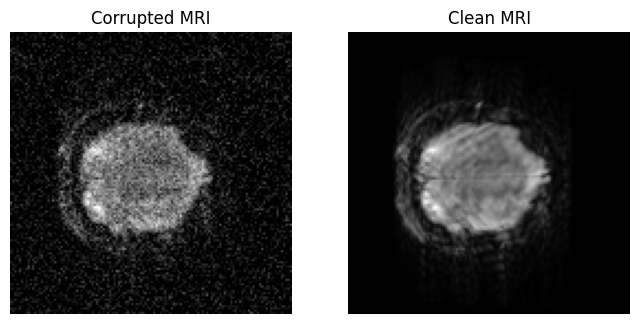

In [ ]:
dataset = ConditionalMRIDataset(
    dataset_path
)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

print(
    "Dataset Ready:",
    len(dataset)
)



corrupted, clean = dataset[0]

fig, ax = plt.subplots(
    1,
    2,
    figsize=(8,4)
)

ax[0].imshow(
    corrupted.squeeze(),
    cmap="gray"
)

ax[0].set_title(
    "Corrupted MRI"
)

ax[0].axis("off")

ax[1].imshow(
    clean.squeeze(),
    cmap="gray"
)

ax[1].set_title(
    "Clean MRI"
)

ax[1].axis("off")

plt.show()

CREATE CONDITIONAL U-NET + NOISE SCHEDULER + OPTIMIZER

In [ ]:
model = UNet2DModel(

    sample_size=128,

    in_channels=2,
    out_channels=1,

    layers_per_block=2,

    block_out_channels=(64, 128, 256, 256),
down_block_types=(
    "DownBlock2D",
    "DownBlock2D",
    "AttnDownBlock2D",
    "DownBlock2D",
),
up_block_types=(
    "UpBlock2D",
    "AttnUpBlock2D",
    "UpBlock2D",
    "UpBlock2D",
),
)

model = model.to("cuda")


noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000
)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

CONDITIONAL TRAINING LOOP

In [ ]:
checkpoint_path = "/content/drive/MyDrive/conditional_mri_checkpoint.pth"

start_epoch = 0

if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    start_epoch = checkpoint['epoch'] + 1

    print(
        f"Resuming from epoch {start_epoch}"
    )

else:

    print("No checkpoint found. Starting fresh.")

No checkpoint found. Starting fresh.


In [ ]:
epochs = 5

model.train()

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}")

    for step, (corrupted_images, clean_images) in enumerate(dataloader):

        corrupted_images = corrupted_images.to("cuda")

        clean_images = clean_images.to("cuda")

        # RANDOM NOISE
        noise = torch.randn_like(clean_images)

        batch_size = clean_images.shape[0]

        # RANDOM TIMESTEPS
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=clean_images.device
        ).long()

        # ADD NOISE TO CLEAN IMAGES
        noisy_images = noise_scheduler.add_noise(
            clean_images,
            noise,
            timesteps
        )

        # MODEL PREDICTS NOISE
        model_input = torch.cat([noisy_images, corrupted_images], dim=1)  # shape: [B, 2, 128, 128]
        noise_pred = model(model_input, timesteps).sample

        # LOSS
        loss = F.mse_loss(
            noise_pred,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if step % 10 == 0:

            print(
                f"Step {step} | Loss: {loss.item():.4f}"
            )


Epoch 1
Step 0 | Loss: 1.1293
Step 10 | Loss: 0.0808
Step 20 | Loss: 0.0580
Step 30 | Loss: 0.0643
Step 40 | Loss: 0.0538
Step 50 | Loss: 0.0453
Step 60 | Loss: 0.0248
Step 70 | Loss: 0.0604
Step 80 | Loss: 0.0390
Step 90 | Loss: 0.0444
Step 100 | Loss: 0.0180
Step 110 | Loss: 0.1465
Step 120 | Loss: 0.0478
Step 130 | Loss: 0.1146
Step 140 | Loss: 0.0242
Step 150 | Loss: 0.0487
Step 160 | Loss: 0.0279
Step 170 | Loss: 0.1422
Step 180 | Loss: 0.1149
Step 190 | Loss: 0.0170
Step 200 | Loss: 0.0147
Step 210 | Loss: 0.0441
Step 220 | Loss: 0.0105
Step 230 | Loss: 0.0425
Step 240 | Loss: 0.1179
Step 250 | Loss: 0.0297
Step 260 | Loss: 0.0150
Step 270 | Loss: 0.0647
Step 280 | Loss: 0.1090
Step 290 | Loss: 0.0082
Step 300 | Loss: 0.0100
Step 310 | Loss: 0.0184
Step 320 | Loss: 0.0106
Step 330 | Loss: 0.0083
Step 340 | Loss: 0.0502
Step 350 | Loss: 0.0315
Step 360 | Loss: 0.0077
Step 370 | Loss: 0.0116
Step 380 | Loss: 0.0188
Step 390 | Loss: 0.0621
Step 400 | Loss: 0.0054
Step 410 | Loss: 0

THE TRAINING PROCESS IS COMPLETED, NOW WE EVELUATE THE MODEL'S PERFORMANCE

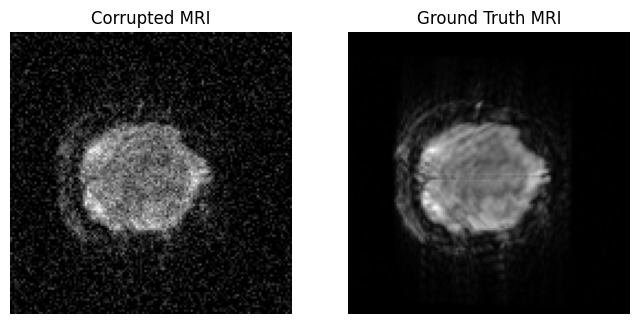

In [ ]:
model.eval()


corrupted_image, clean_image = dataset[0]


fig, ax = plt.subplots(
    1,
    2,
    figsize=(8,4)
)

ax[0].imshow(
    corrupted_image.squeeze(),
    cmap="gray"
)

ax[0].set_title(
    "Corrupted MRI"
)

ax[0].axis("off")

ax[1].imshow(
    clean_image.squeeze(),
    cmap="gray"
)

ax[1].set_title(
    "Ground Truth MRI"
)

ax[1].axis("off")

plt.show()

WE PREPARED AN INPUT FOR THE MODEL AND LIGHT NOISE INTO IT

In [ ]:
input_image = corrupted_image.unsqueeze(0).to("cuda")


noise = torch.randn_like(input_image)

timesteps = torch.tensor([500]).to("cuda")

noisy_input = noise_scheduler.add_noise(
    input_image,
    noise,
    timesteps
)

MODEL RECONSTRUCTION + REMOVE PREDICTED NOISE AND THEN CONVERT OT IMAGE

In [ ]:
with torch.no_grad():

    predicted_noise = model(
        noisy_input,
        timesteps
    ).sample


reconstructed = noisy_input - predicted_noise


reconstructed_image = (
    reconstructed.squeeze()
    .cpu()
    .numpy()
)

reconstructed_image = (
    reconstructed_image * 0.5
) + 0.5

VISUALIZATION OF THE RESULT

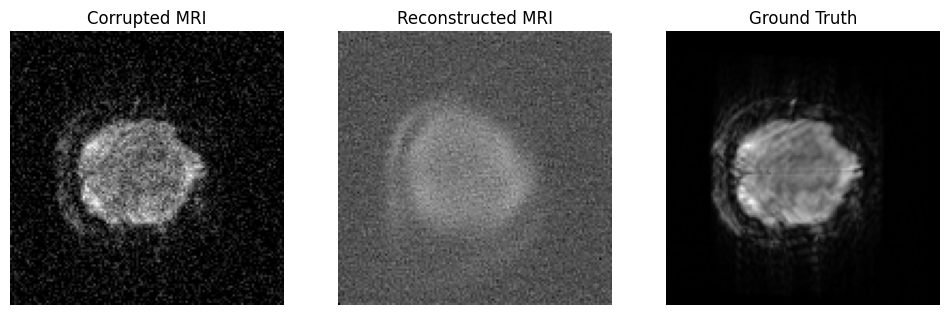

In [ ]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(12,4)
)

ax[0].imshow(
    corrupted_image.squeeze(),
    cmap="gray"
)

ax[0].set_title(
    "Corrupted MRI"
)

ax[0].axis("off")

ax[1].imshow(
    reconstructed_image,
    cmap="gray"
)

ax[1].set_title(
    "Reconstructed MRI"
)

ax[1].axis("off")

ax[2].imshow(
    clean_image.squeeze(),
    cmap="gray"
)

ax[2].set_title(
    "Ground Truth"
)

ax[2].axis("off")

plt.show()

MATHEMATICAL EVALUATION OF THE MODEL

In [ ]:
!pip install scikit-image


In [ ]:
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity
)

In [ ]:
import numpy as np

# CLEAN IMAGE
ground_truth = clean_image.squeeze().cpu().numpy()

# RECONSTRUCTED IMAGE
reconstructed_eval = reconstructed.squeeze().cpu().numpy()

# NORMALIZE BOTH
ground_truth = (ground_truth + 1) / 2
reconstructed_eval = (reconstructed_eval + 1) / 2

# CLIP VALUES
ground_truth = np.clip(
    ground_truth,
    0,
    1
)

reconstructed_eval = np.clip(
    reconstructed_eval,
    0,
    1
)

# MSE
mse_value = mean_squared_error(
    ground_truth,
    reconstructed_eval
)

# PSNR
psnr_value = peak_signal_noise_ratio(
    ground_truth,
    reconstructed_eval,
    data_range=1.0
)

# SSIM
ssim_value = structural_similarity(
    ground_truth,
    reconstructed_eval,
    data_range=1.0
)

print(f"MSE  : {mse_value:.4f}")
print(f"PSNR : {psnr_value:.4f}")
print(f"SSIM : {ssim_value:.4f}")